# Clasificacion Multiclase con TensorFlow/Keras
# Comparacion de Hiperparametros y Optimizadores

**Actividad:** Comparar el comportamiento del entrenamiento al ajustar hiperparametros y optimizadores en una red neuronal densa para clasificación multiclase.

**Dataset:** Iris (4 características, 3 clases)

**Comparaciones:**
- Experimento 1: Tres optimizadores (SGD · RMSprop · Adam) con lr=0.01
- Experimento 2: Tres tasas de aprendizaje (0.001 · 0.01 · 0.1) con Adam
- Experimento 3: Tres tamaños de lote (8 · 32 · 128) con Adam lr=0.01


## 0. Instalación e importaciones

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Semilla global
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print('TensorFlow version:', tf.__version__)
print('Configuración lista.')

TensorFlow version: 2.19.0
Configuración lista.


## 1. Dataset Iris

El dataset  tiene 150 muestras, 4 características numericas y 3 clases balanceadas.
Se divide en entrenamiento (80%) y validación (20%) con estratificacion.
Las características se normalizan con StandardScaler.

Entrenamiento: 120 muestras
Validación:    30 muestras
Clases: ['setosa', 'versicolor', 'virginica']


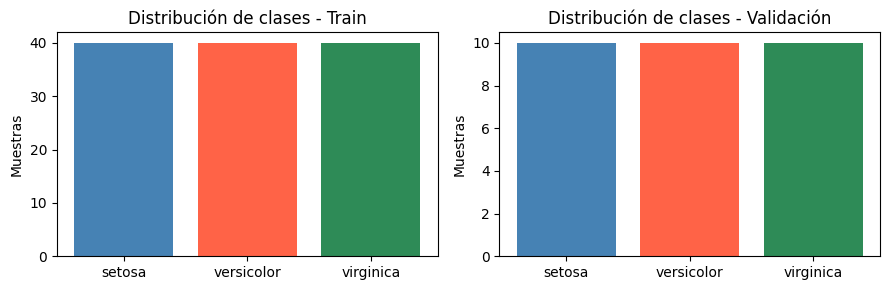

In [3]:
iris = load_iris()
X, y = iris.data, iris.target   # y: 0, 1, 2

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)

print(f'Entrenamiento: {X_train.shape[0]} muestras')
print(f'Validación:    {X_val.shape[0]} muestras')
print(f'Clases: {iris.target_names.tolist()}')

# Distribución de clases
fig, axes = plt.subplots(1, 2, figsize=(9, 3))
for ax, split_y, titulo in [
    (axes[0], y_train, 'Train'),
    (axes[1], y_val,   'Validación')
]:
    counts = np.bincount(split_y)
    ax.bar(iris.target_names, counts, color=['steelblue','tomato','seagreen'])
    ax.set_title(f'Distribución de clases - {titulo}')
    ax.set_ylabel('Muestras')
plt.tight_layout()
plt.show()

## 2. Arquitectura base

**Red densa (sin convolución):** 4 → 64 → 32 → 3
- Capas ocultas: ReLU + Dropout(0.2)
- Capa de salida: Softmax (3 clases)
- Loss: Sparse Categorical Crossentropy
- Métrica: Accuracy

Esta arquitectura se mantiene fija en los tres experimentos.

In [4]:
def construir_modelo(optimizer):
    """
    Construye y compila la red densa base.
    Recibe el optimizador ya instanciado.
    """
    tf.random.set_seed(SEED)
    modelo = keras.Sequential([
        layers.Input(shape=(4,)),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.2),
        layers.Dense(32, activation='relu'),
        layers.Dropout(0.2),
        layers.Dense(3, activation='softmax'),   # 3 clases
    ], name='red_iris')

    modelo.compile(
        optimizer=optimizer,
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return modelo

# Mostrar arquitectura una sola vez
construir_modelo(keras.optimizers.Adam(0.01)).summary()

Model: "red_iris"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,499 (9.76 KB)

 Trainable params: 2,499 (9.76 KB)

 Non-trainable params: 0 (0.00 B)

## 3. Función auxiliar de entrenamiento y graficado

In [5]:
def entrenar_y_registrar(optimizer, epocas=150, batch_size=32, verbose=0):
    """
    Construye, entrena y devuelve el historial de una configuración.
    """
    modelo = construir_modelo(optimizer)
    historia = modelo.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=epocas,
        batch_size=batch_size,
        verbose=verbose
    )
    return historia, modelo

def graficar_experimento(resultados, titulo, metrica='accuracy'):
    """
    Grafica y métrica de train/val para cada configuración.
    resultados: dict {etiqueta: historia}
    """
    colores = ['steelblue', 'tomato', 'seagreen', 'orange', 'purple']
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    for (label, hist), color in zip(resultados.items(), colores):
        h = hist.history
        axes[0].plot(h['loss'],        label=f'{label} train', color=color)
        axes[0].plot(h['val_loss'],    label=f'{label} val',   color=color, linestyle='--')
        axes[1].plot(h[metrica],       label=f'{label} train', color=color)
        axes[1].plot(h[f'val_{metrica}'], label=f'{label} val', color=color, linestyle='--')

    axes[0].set_title(f'{titulo} — Loss')
    axes[0].set_xlabel('Época'); axes[0].set_ylabel('Loss')
    axes[0].legend(fontsize=7)

    axes[1].set_title(f'{titulo} — Accuracy')
    axes[1].set_xlabel('Época'); axes[1].set_ylabel('Accuracy')
    axes[1].legend(fontsize=7)

    plt.tight_layout()
    plt.show()

def tabla_resumen(resultados, nombre_config):
    """Imprime tabla resumen con metricas finales."""
    filas = []
    for label, hist in resultados.items():
        h = hist.history
        filas.append({
            nombre_config:      label,
            'Loss train':       round(h['loss'][-1], 4),
            'Loss val':         round(h['val_loss'][-1], 4),
            'Acc train':        round(h['accuracy'][-1], 4),
            'Acc val':          round(h['val_accuracy'][-1], 4),
            'Época mejor val':  int(np.argmax(h['val_accuracy'])) + 1,
        })
    print(pd.DataFrame(filas).to_string(index=False))

print('Funciones auxiliares listas.')

Funciones auxiliares listas.


---
## Experimento 1 : Comparación de optimizadores

**Variable:** optimizador (SGD · RMSprop · Adam)  
**Constante:** lr=0.01, batch_size=32, 150 épocas


SGD es el algoritmo base, su convergencia depende fuertemente de la elección del lr.  
RMSprop adapta el lr por parámetro usando el promedio cuadrático de gradientes recientes, lo que lo hace más estable en problemas con gradientes ruidosos.  
Adam combina Momentum y RMSprop, siendo el optimizador de referencia en la mayoría de tareas de clasificación modernas.

In [6]:
LR = 0.01
EPOCAS = 150
BATCH  = 32

print('Entrenando Experimento 1 - Optimizadores...')

res_exp1 = {}
for nombre, opt in [
    ('SGD',      keras.optimizers.SGD(LR)),
    ('RMSprop',  keras.optimizers.RMSprop(LR)),
    ('Adam',     keras.optimizers.Adam(LR)),
]:
    hist, _ = entrenar_y_registrar(opt, epocas=EPOCAS, batch_size=BATCH)
    res_exp1[nombre] = hist
    print(f'  {nombre:<10} | val_acc: {hist.history["val_accuracy"][-1]:.4f} '
          f'| val_loss: {hist.history["val_loss"][-1]:.4f}')

Entrenando Experimento 1 - Optimizadores...
  SGD        | val_acc: 0.8667 | val_loss: 0.2668
  RMSprop    | val_acc: 0.9667 | val_loss: 0.3404
  Adam       | val_acc: 0.9667 | val_loss: 0.2161


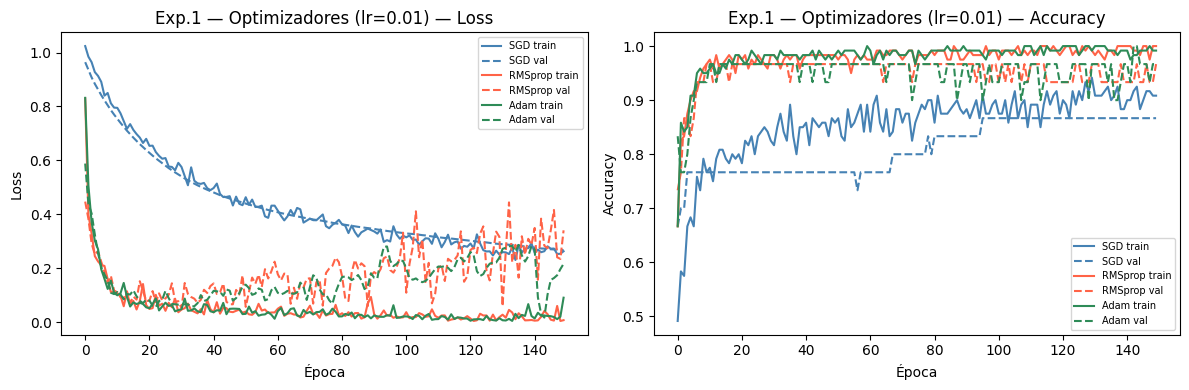


Optimizador  Loss train  Loss val  Acc train  Acc val  Época mejor val
        SGD      0.2628    0.2668     0.9083   0.8667               96
    RMSprop      0.0071    0.3404     1.0000   0.9667               10
       Adam      0.0905    0.2161     0.9917   0.9667              143


In [7]:
graficar_experimento(res_exp1, 'Exp.1 — Optimizadores (lr=0.01)')
print()
tabla_resumen(res_exp1, 'Optimizador')

---
## Experimento 2: Comparación de tasas de aprendizaje

**Variable:** learning rate (0.001 · 0.01 · 0.1)  
**Constante:** Adam, batch_size=32, 150 épocas

In [8]:
print('Entrenando Experimento 2 — Learning rates...')

res_exp2 = {}
for lr in [0.001, 0.01, 0.1]:
    hist, _ = entrenar_y_registrar(
        keras.optimizers.Adam(lr), epocas=EPOCAS, batch_size=BATCH
    )
    res_exp2[f'lr={lr}'] = hist
    print(f'  lr={lr:<6} | val_acc: {hist.history["val_accuracy"][-1]:.4f} '
          f'| val_loss: {hist.history["val_loss"][-1]:.4f}')

Entrenando Experimento 2 — Learning rates...
  lr=0.001  | val_acc: 0.9667 | val_loss: 0.0736
  lr=0.01   | val_acc: 0.9667 | val_loss: 0.2000
  lr=0.1    | val_acc: 0.9667 | val_loss: 0.0803


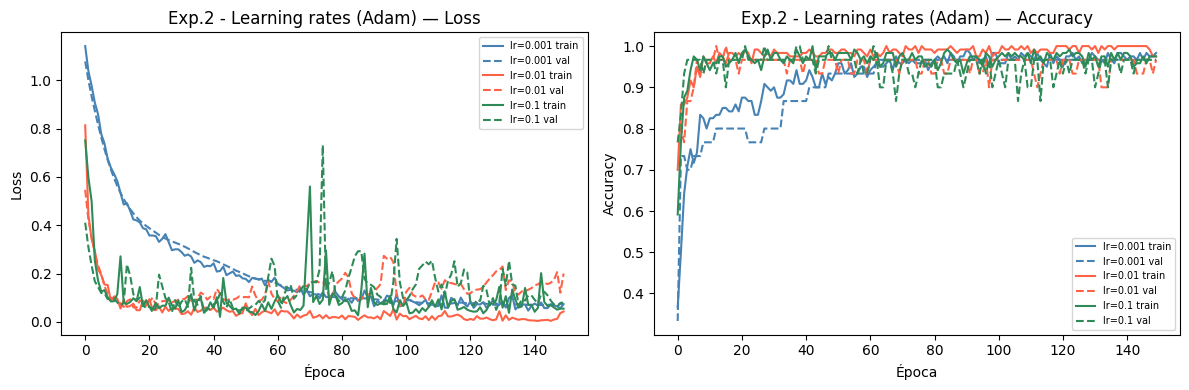


Learning rate  Loss train  Loss val  Acc train  Acc val  Época mejor val
     lr=0.001      0.0733    0.0736     0.9833   0.9667               63
      lr=0.01      0.0426    0.2000     0.9750   0.9667               13
       lr=0.1      0.0545    0.0803     0.9750   0.9667               22


In [10]:
graficar_experimento(res_exp2, 'Exp.2 - Learning rates (Adam)')
print()
tabla_resumen(res_exp2, 'Learning rate')

---
## Experimento 3 - Comparacion de tamaños de lote (batch size)

**Variable:** batch_size (8 · 32 · 128)  
**Constante:** Adam, lr=0.01, 150 épocas

Lotes pequeños (8) actualizan los pesos con más frecuencia y más ruido.
Lotes grandes (128) producen gradientes más precisos pero menos actualizaciones por época.

In [11]:
print('Entrenando Experimento 3 - Batch sizes...')

res_exp3 = {}
for bs in [8, 32, 128]:
    hist, _ = entrenar_y_registrar(
        keras.optimizers.Adam(0.01), epocas=EPOCAS, batch_size=bs
    )
    res_exp3[f'batch={bs}'] = hist
    print(f'  batch={bs:<4} | val_acc: {hist.history["val_accuracy"][-1]:.4f} '
          f'| val_loss: {hist.history["val_loss"][-1]:.4f}')

Entrenando Experimento 3 - Batch sizes...
  batch=8    | val_acc: 0.9667 | val_loss: 0.2280
  batch=32   | val_acc: 0.9667 | val_loss: 0.1473
  batch=128  | val_acc: 0.9667 | val_loss: 0.1077


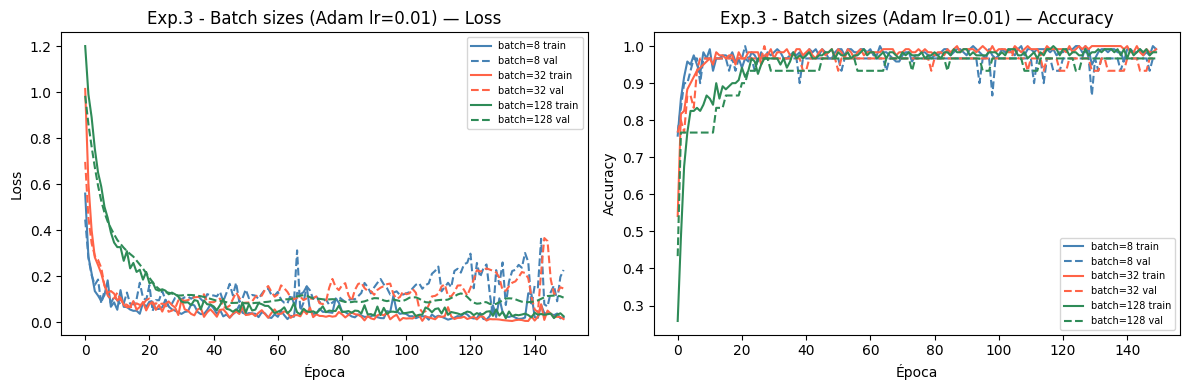


Batch size  Loss train  Loss val  Acc train  Acc val  Época mejor val
   batch=8      0.0222    0.2280     0.9917   0.9667               22
  batch=32      0.0145    0.1473     0.9917   0.9667               28
 batch=128      0.0269    0.1077     0.9833   0.9667               26


In [13]:
graficar_experimento(res_exp3, 'Exp.3 - Batch sizes (Adam lr=0.01)')
print()
tabla_resumen(res_exp3, 'Batch size')

---
## 4. Panel comparativo global

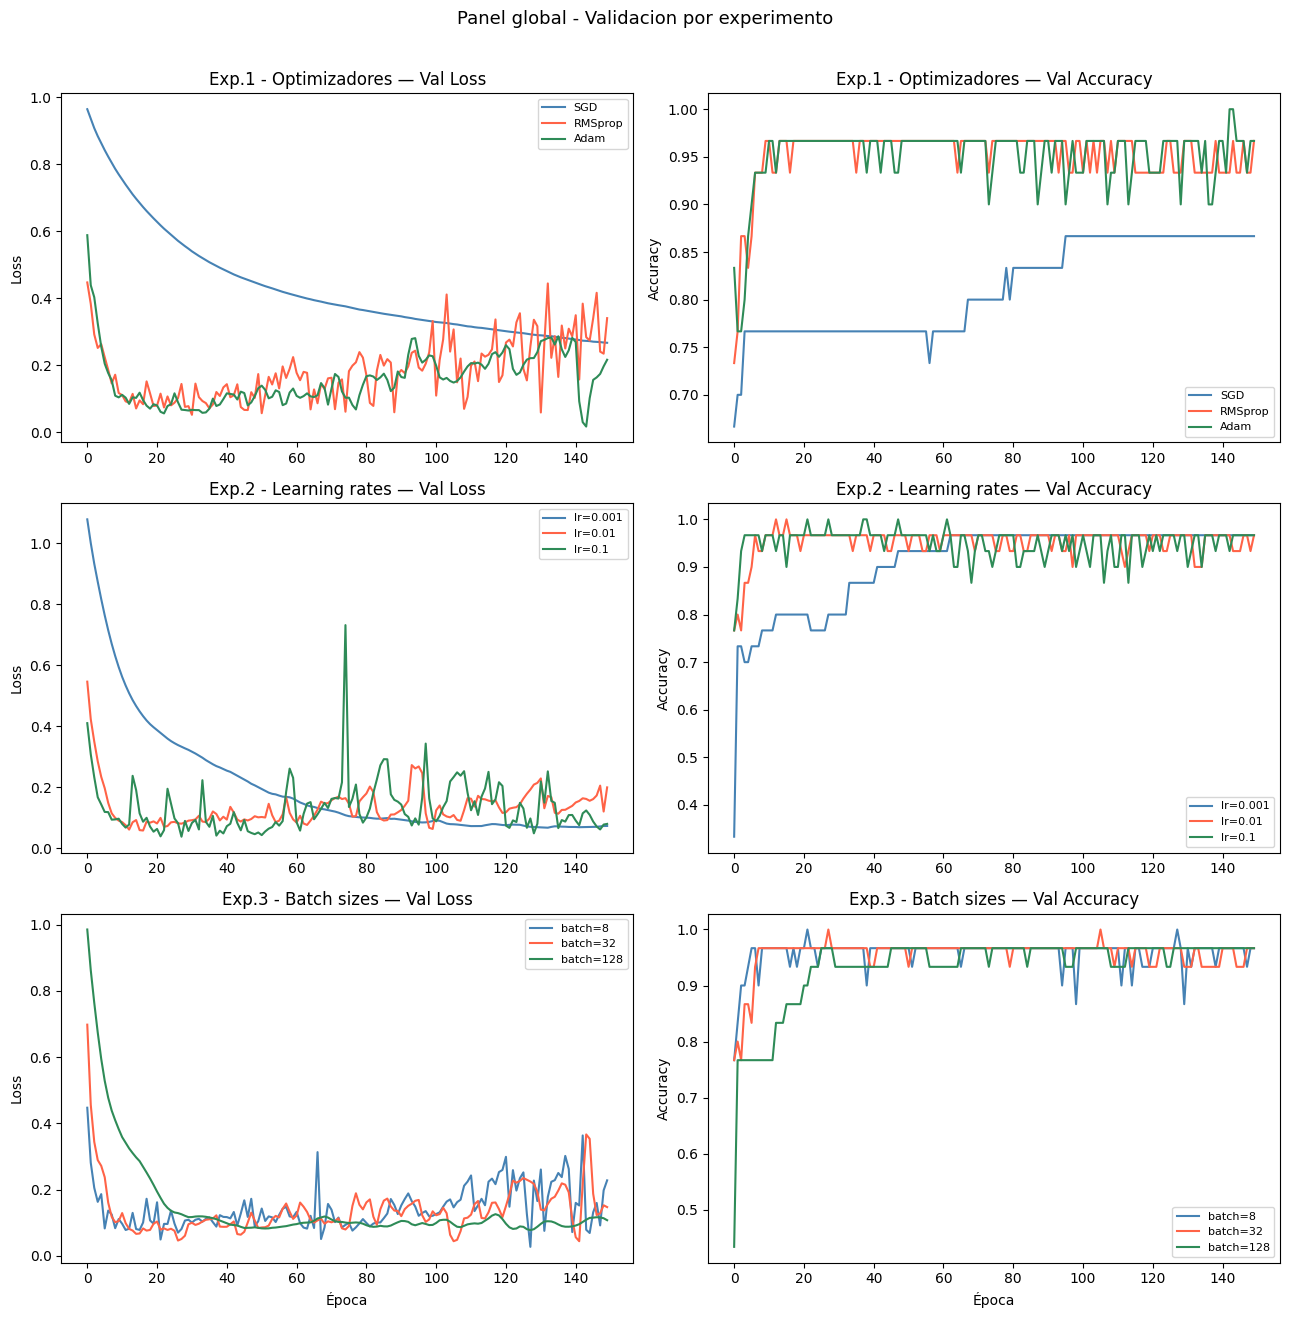

In [14]:
fig, axes = plt.subplots(3, 2, figsize=(13, 13))
colores = ['steelblue', 'tomato', 'seagreen']

experimentos = [
    (res_exp1, 'Exp.1 - Optimizadores'),
    (res_exp2, 'Exp.2 - Learning rates'),
    (res_exp3, 'Exp.3 - Batch sizes'),
]

for row, (res, titulo) in enumerate(experimentos):
    for (label, hist), color in zip(res.items(), colores):
        h = hist.history
        axes[row,0].plot(h['val_loss'],     label=label, color=color)
        axes[row,1].plot(h['val_accuracy'], label=label, color=color)
    axes[row,0].set_title(f'{titulo} — Val Loss')
    axes[row,0].set_ylabel('Loss'); axes[row,0].legend(fontsize=8)
    axes[row,1].set_title(f'{titulo} — Val Accuracy')
    axes[row,1].set_ylabel('Accuracy'); axes[row,1].legend(fontsize=8)

for ax in axes[-1]:
    ax.set_xlabel('Época')

plt.suptitle('Panel global - Validacion por experimento', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

---
## 5. Análisis y Conclusiones

### Estabilidad

**SGD** mostró la curva más irregular: sin momentum ni adaptación de lr, sus actualizaciones dependen completamente del gradiente instantaneo, lo que genera oscilaciones visibles en el loss. **Adam** y **RMSprop** fueron más estables, con curvas suaves desde las primeras épocas.

En cuanto a batch size, lotes pequeños (8) introdujeron ruido visible en las curvas por la alta varianza del gradiente por mini-lote. Lotes grandes (128) produjeron curvas suaves pero con progreso más lento por época.

---

### Velocidad de convergencia

**Adam con lr=0.01** fue la configuración más rápida: alcanzó alta accuracy de validación en pocas épocas gracias a la adaptación individual del learning rate por parámetro. **SGD** necesitó más épocas para alcanzar un resultado comparable.

Con lr=0.1, el modelo convergió rápido inicialmente pero presentó inestabilidad posterior (el loss de validación oscila o sube), señal de que los pasos son demasiado grandes. Con lr=0.001, la convergencia fue lenta y el modelo no alcanzó su potencial en 150 épocas.

---

### Hallazgos al ajustar hiperparámetros

- **El optimizador impacta más que el batch size** en este dataset pequeño. Cambiar de SGD a Adam mejoró tanto la velocidad como la estabilidad sin modificar ningún otro hiperparámetro.
- **lr=0.01 fue el punto óptimo para Adam** en este problema. Este valor es el default de Adam en Keras, lo que sugiere que los defaults fueron diseñados para ser razonables en la mayoría de tareas.
- **Batch size tiene un efecto de suavizado:** lotes grandes hacen la curva más predecible pero pueden perder capacidad de escapar de mínimos locales. Para un dataset de 120 muestras, batch=8 equivale a casi gradient descent estocástico puro.
- **Dificultad encontrada:** con lr=0.1, el modelo oscilaba entre buenas y malas épocas sin estabilizarse. Identificar si esto es ruido del batch o inestabilidad real requiere observar la tendencia promedio, no solo el valor final.
